**1) Implemente o método da Bisseção descrito pelo algoritmo 1.1 no texto. Para testar o algoritmo, use os exemplos do material textual.**

In [ ]:
import numpy as np
import pandas as pd

def bissecao(f, a, b, tol=1e-6, max_iter=100):
    # Inicialização das variáveis e cálculo inicial de f(a) e f(b)
    fa = f(a)
    fb = f(b)

    # Verificação de existência de raiz no intervalo (Teorema do Valor Intermediário)
    if np.sign(fa) * np.sign(fb) >= 0:
        print("Erro: Não há garantia de raiz neste intervalo (sinais iguais).")
        return None, None

    historico = []

    # Loop principal
    for i in range(max_iter):
        # Cálculo otimizado do ponto médio para evitar overflow
        x = a + 0.5 * (b - a)
        fx = f(x)

        # Cálculo do erro estimado (metade do intervalo atual)
        erro = (b - a) / 2

        # Armazena dados da iteração
        historico.append({
            'Iteração': i + 1,
            'a': a,
            'b': b,
            'x': x,
            'f(x)': fx,
            'Erro Abs': erro
        })

        # Critérios de parada: raiz exata ou tolerância atingida
        if fx == 0 or erro < tol:
            return x, pd.DataFrame(historico)

        # Atualização dos limites (Otimização: reutiliza fa ou fx)
        if np.sign(fa) * np.sign(fx) < 0:
            b = x
            # fb assume fx implicitamente, não precisa recalcular
        else:
            a = x
            fa = fx # Atualiza fa para a próxima iteração

    print("Número máximo de iterações atingido.")
    return x, pd.DataFrame(historico)

In [ ]:
# Teste com o Exemplo 1.4 do texto
f_teste = lambda x: 2 - np.exp(x)

raiz, dados = bissecao(f_teste, 0, 1)

print(f"Raiz encontrada: {raiz}")
display(dados.head())

Raiz encontrada: 0.6931467056274414


,Iteração,a,b,x,f(x),Erro Abs
0,1,0.0000,1.00,0.50000,0.351279,0.50000
1,2,0.5000,1.00,0.75000,-0.117000,0.25000
2,3,0.5000,0.75,0.62500,0.131754,0.12500
3,4,0.6250,0.75,0.68750,0.011263,0.06250
4,5,0.6875,0.75,0.71875,-0.051867,0.03125


**2) Determine as raízes reais de f (x) = −0.5x 2 + 2.5x + 4.5:**

(a) Graficamente:

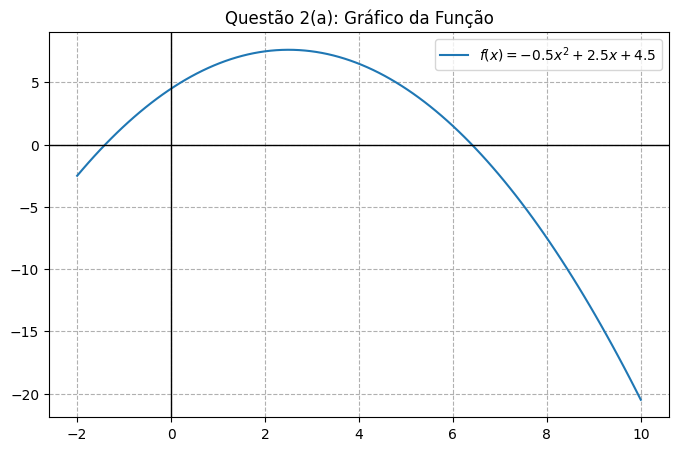

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definição da função
def f(x):
    return -0.5 * x**2 + 2.5 * x + 4.5

# Gerando o gráfico
x = np.linspace(-2, 10, 100)
y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$f(x) = -0.5x^2 + 2.5x + 4.5$')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--')
plt.title('Questão 2(a): Gráfico da Função')
plt.legend()
plt.show()

(b) Usando a fórmula quadrática

In [ ]:
# Coeficientes da equação: ax^2 + bx + c
a, b, c = -0.5, 2.5, 4.5

# Cálculo do delta
delta = b**2 - 4 * a * c

# Fórmula de Bhaskara
raiz1 = (-b + np.sqrt(delta)) / (2 * a)
raiz2 = (-b - np.sqrt(delta)) / (2 * a)

# Identificando a maior raiz (alvo do problema)
valor_verdadeiro = max(raiz1, raiz2)

print(f"Raízes encontradas: {raiz1:.6f} e {raiz2:.6f}")
print(f"Maior raiz (Valor Verdadeiro): {valor_verdadeiro:.6f}")

Raízes encontradas: -1.405125 e 6.405125
Maior raiz (Valor Verdadeiro): 6.405125


**(c) Usando três iterações do método da bisseção para determinar a maior raiz. Use as aproximações iniciais xl = 5 e xu = 10. Calcule o erro relativo obtido entre cada iteração, e o erro entre os valores verdadeiros encontrados no item b e o valor de cada iteração.**

In [ ]:
# Configuração inicial
xl = 5.0
xu = 10.0
xr_ant = 0
iteracoes = 3

print(f"{'Iter':<5} {'xl':<10} {'xu':<10} {'xr':<10} {'Erro Rel.(%)':<15} {'Erro Verdadeiro':<15}")

for i in range(iteracoes):
    # 1. Ponto médio
    xr = (xl + xu) / 2

    # 2. Cálculos de erro
    if i == 0:
        erro_rel = np.nan # Não há erro relativo na 1ª iteração
    else:
        erro_rel = abs((xr - xr_ant) / xr) * 100

    erro_verdadeiro = abs(valor_verdadeiro - xr)

    # Exibir resultados
    erro_str = f"{erro_rel:.4f}" if not np.isnan(erro_rel) else "-"
    print(f"{i+1:<5} {xl:<10.4f} {xu:<10.4f} {xr:<10.4f} {erro_str:<15} {erro_verdadeiro:<15.6f}")

    # 3. Teste para novo intervalo
    if f(xl) * f(xr) < 0:
        xu = xr
    else:
        xl = xr

    xr_ant = xr

Iter  xl         xu         xr         Erro Rel.(%)    Erro Verdadeiro
1     5.0000     10.0000    7.5000     -               1.094875       
2     5.0000     7.5000     6.2500     20.0000         0.155125       
3     6.2500     7.5000     6.8750     9.0909          0.469875       


3) Localize a primeira raiz não-trivial de $\sin(x) = x^3$, onde $x$ está em radianos. Use uma técnica gráfica e a bisseção com o intervalo inicial de 0,5 a 1. Faça os cálculos até que o erro seja inferior a 2%.

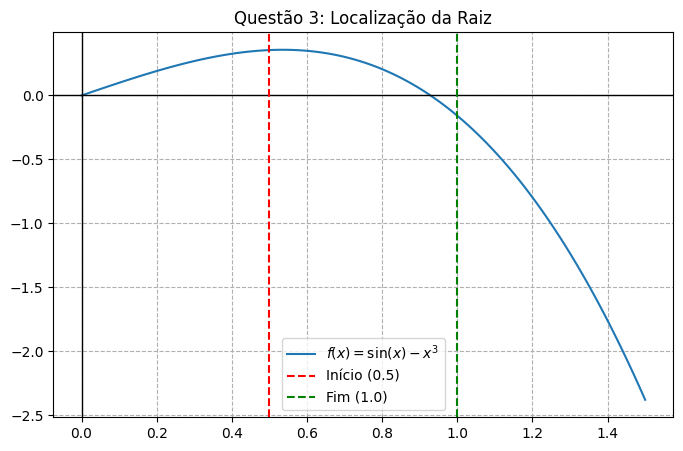

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos a função f(x) = sin(x) - x^3
# Queremos encontrar onde f(x) = 0
def f(x):
    return np.sin(x) - x**3

# Criando o gráfico no intervalo próximo de [0.5, 1]
x = np.linspace(0, 1.5, 100)
y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$f(x) = \sin(x) - x^3$')
plt.axhline(0, color='black', linewidth=1) # Linha do zero
plt.axvline(0, color='black', linewidth=1)
plt.axvline(0.5, color='red', linestyle='--', label='Início (0.5)')
plt.axvline(1.0, color='green', linestyle='--', label='Fim (1.0)')
plt.grid(True, linestyle='--')
plt.title('Questão 3: Localização da Raiz')
plt.legend()
plt.show()

In [ ]:
# Configuração inicial
xl = 0.5
xu = 1.0
xr_ant = 0
tol = 2.0  # Tolerância de 2%
erro_rel = 100.0 # Valor inicial alto para entrar no loop
iteracao = 0

print(f"{'Iter':<5} {'xl':<10} {'xu':<10} {'xr':<10} {'Erro Rel.(%)':<15}")

# Loop continua enquanto o erro for maior ou igual a 2%
while erro_rel >= tol:
    iteracao += 1

    # 1. Ponto médio
    xr = (xl + xu) / 2

    # 2. Cálculo do erro relativo (a partir da 2ª iteração)
    if iteracao > 1:
        erro_rel = abs((xr - xr_ant) / xr) * 100
    else:
        erro_rel = 100.0 # Primeira iteração não tem erro calculado, mantemos alto

    # Exibir resultados
    erro_str = f"{erro_rel:.4f}" if iteracao > 1 else "-"
    print(f"{iteracao:<5} {xl:<10.6f} {xu:<10.6f} {xr:<10.6f} {erro_str:<15}")

    # 3. Atualização do intervalo
    if f(xl) * f(xr) < 0:
        xu = xr
    else:
        xl = xr

    xr_ant = xr

print(f"\nRaiz aproximada encontrada: {xr:.6f} com erro de {erro_rel:.4f}%")

Iter  xl         xu         xr         Erro Rel.(%)   
1     0.500000   1.000000   0.750000   -              
2     0.750000   1.000000   0.875000   14.2857        
3     0.875000   1.000000   0.937500   6.6667         
4     0.875000   0.937500   0.906250   3.4483         
5     0.906250   0.937500   0.921875   1.6949         

Raiz aproximada encontrada: 0.921875 com erro de 1.6949%


**4) Dada $f(x)=-2x^{6}-1.5x^{4}+10x+20,$ encontre o máximo dessa função $(f^{\prime}(x)=0)$ usando o método da bisseção, considerando o intervalo $[0, 1]$ e um erro limite de 5%.**

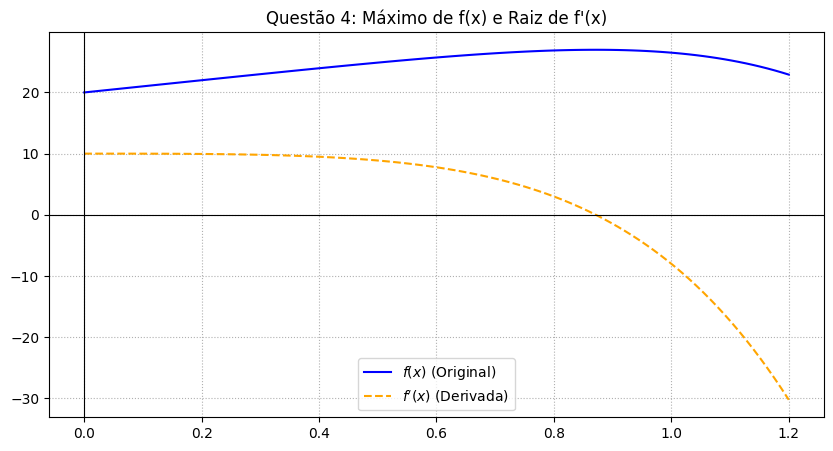


Iter  xl         xu         xr (Raiz)    Erro Rel.(%)   
1     0.000000   1.000000   0.500000   -              
2     0.500000   1.000000   0.750000   33.3333        
3     0.750000   1.000000   0.875000   14.2857        
4     0.750000   0.875000   0.812500   7.6923         
5     0.812500   0.875000   0.843750   3.7037         

O máximo ocorre em x ≈ 0.843750
Valor máximo da função: 26.955641


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definição das Funções ---
# Função original: f(x) = -2x^6 - 1.5x^4 + 10x + 20
def f(x):
    return -2 * x**6 - 1.5 * x**4 + 10 * x + 20

# Derivada: f'(x) = -12x^5 - 6x^3 + 10
# O máximo ocorre onde f'(x) = 0
def df(x):
    return -12 * x**5 - 6 * x**3 + 10

# --- 2. Análise Gráfica ---
x_vals = np.linspace(0, 1.2, 100)
y_orig = f(x_vals)
y_deriv = df(x_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_orig, label=r'$f(x)$ (Original)', color='blue')
plt.plot(x_vals, y_deriv, label=r"$f'(x)$ (Derivada)", color='orange', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle=':')
plt.legend()
plt.title('Questão 4: Máximo de f(x) e Raiz de f\'(x)')
plt.show()

# --- 3. Método da Bisseção (Aplicado na Derivada) ---
xl = 0.0
xu = 1.0
xr_ant = 0
tol = 5.0  # Erro limite de 5%
erro_rel = 100.0
iteracao = 0

print(f"\n{'Iter':<5} {'xl':<10} {'xu':<10} {'xr (Raiz)':<12} {'Erro Rel.(%)':<15}")

while erro_rel >= tol:
    iteracao += 1

    # Ponto médio
    xr = (xl + xu) / 2

    # Cálculo do erro relativo (a partir da 2ª iteração)
    if iteracao > 1:
        erro_rel = abs((xr - xr_ant) / xr) * 100
    else:
        erro_rel = 100.0

    erro_str = f"{erro_rel:.4f}" if iteracao > 1 else "-"
    print(f"{iteracao:<5} {xl:<10.6f} {xu:<10.6f} {xr:<10.6f} {erro_str:<15}")

    # Teste de sinal na DERIVADA
    if df(xl) * df(xr) < 0:
        xu = xr
    else:
        xl = xr

    xr_ant = xr

# Resultados Finais
max_valor = f(xr)
print(f"\nO máximo ocorre em x ≈ {xr:.6f}")
print(f"Valor máximo da função: {max_valor:.6f}")

Embora a bisseção seja uma técnica perfeitamente válida para determinar raízes, sua abordagem do tipo 'força bruta' é relativamente ineficiente1. A falsa posição é uma alternativa baseada na percepção gráfica2.Um método alternativo que explora essa percepção gráfica é ligar $f(x_{l})$ e $f(x_{u})$ por uma reta3. A intersecção dessa reta com o eixo x representa uma estimativa melhorada da raiz4.A aproximação da raiz é dada por:$$x^{*}=x_{u}-\frac{f(x_{u})(x_{l}-x_{u})}{f(x_{l})-f(x_{u}))}$$As bibliotecas numéricas do Python não trazem uma implementação desse método6. Implemente-o, teste-o com os exemplos do texto, comparando com o método da bisseção. Mostre que esse método, para vários casos, é mais eficiente que o da bisseção7.

In [ ]:
import numpy as np
import pandas as pd

# 1. Função de Teste (Usando o exemplo da Questão 3)
# f(x) = sin(x) - x^3
def f(x):
    return np.sin(x) - x**3

# 2. Implementação do Método da Bisseção (Para comparação)
def bissecao(f, xl, xu, tol=1e-6, max_iter=100):
    xr_ant = 0
    hist = []

    for i in range(max_iter):
        xr = (xl + xu) / 2  # Ponto médio simples

        # Cálculo do erro relativo
        if i == 0:
            erro = 100.0
        else:
            erro = abs((xr - xr_ant) / xr) * 100

        hist.append([i+1, xl, xu, xr, erro, f(xr)])

        # Critério de parada
        if erro < tol or abs(f(xr)) < 1e-15:
            break

        # Atualização do intervalo
        if f(xl) * f(xr) < 0:
            xu = xr
        else:
            xl = xr
        xr_ant = xr

    return pd.DataFrame(hist, columns=['Iter', 'xl', 'xu', 'xr', 'Erro(%)', 'f(xr)'])

# 3. Implementação do Método da Falsa Posição (Regula Falsi)
def falsa_posicao(f, xl, xu, tol=1e-6, max_iter=100):
    xr_ant = 0
    hist = []

    for i in range(max_iter):
        fxl = f(xl)
        fxu = f(xu)

        # FÓRMULA DA FALSA POSIÇÃO (Média Ponderada)
        xr = xu - (fxu * (xl - xu)) / (fxl - fxu)
        fxr = f(xr)

        # Cálculo do erro relativo
        if i == 0:
            erro = 100.0
        else:
            erro = abs((xr - xr_ant) / xr) * 100

        hist.append([i+1, xl, xu, xr, erro, fxr])

        # Critério de parada
        if erro < tol or abs(fxr) < 1e-15:
            break

        # Atualização do intervalo (Mesma lógica da bisseção)
        if fxl * fxr < 0:
            xu = xr
        else:
            xl = xr
        xr_ant = xr

    return pd.DataFrame(hist, columns=['Iter', 'xl', 'xu', 'xr', 'Erro(%)', 'f(xr)'])

# --- 4. Execução e Comparativo ---
xl_ini, xu_ini = 0.5, 1.0
tolerancia = 2.0 # 2% (mesma da questão 3 para comparação justa)

print(f"Comparativo: f(x) = sin(x) - x^3 no intervalo [{xl_ini}, {xu_ini}]")
print(f"Tolerância de Erro: {tolerancia}%\n")

# Rodando Bisseção
df_bis = bissecao(f, xl_ini, xu_ini, tol=tolerancia)
print("--- Método da Bisseção ---")
print(df_bis[['Iter', 'xr', 'Erro(%)', 'f(xr)']].to_string(index=False))
print(f"Total de Iterações: {len(df_bis)}\n")

# Rodando Falsa Posição
df_fp = falsa_posicao(f, xl_ini, xu_ini, tol=tolerancia)
print("--- Método da Falsa Posição ---")
print(df_fp[['Iter', 'xr', 'Erro(%)', 'f(xr)']].to_string(index=False))
print(f"Total de Iterações: {len(df_fp)}\n")

# Conclusão Automática
if len(df_fp) < len(df_bis):
    print(f"CONCLUSÃO: A Falsa Posição foi mais eficiente ({len(df_fp)} iterações contra {len(df_bis)}).")
else:
    print("CONCLUSÃO: A Bisseção foi mais eficiente ou equivalente.")

Comparativo: f(x) = sin(x) - x^3 no intervalo [0.5, 1.0]
Tolerância de Erro: 2.0%

--- Método da Bisseção ---
 Iter       xr    Erro(%)     f(xr)
    1 0.750000 100.000000  0.259764
    2 0.875000  14.285714  0.097622
    3 0.937500   6.666667 -0.017894
    4 0.906250   3.448276  0.042903
    5 0.921875   1.694915  0.013277
Total de Iterações: 5

--- Método da Falsa Posição ---
 Iter       xr    Erro(%)    f(xr)
    1 0.845475 100.000000 0.143918
    2 0.919005   8.001059 0.018835
    3 0.927606   0.927239 0.002025
Total de Iterações: 3

CONCLUSÃO: A Falsa Posição foi mais eficiente (3 iterações contra 5).
